


<font face="Times New Roman" size=5>
<div dir=rtl align="center">


<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology
</font>
<br>
<font color="#008080" size=6>
  Machine Learning in nano applications
</font>

<hr/>
<font color="#80a080" size=5>
Course Home Work-1
<br>
</font>
<font size=5>
Instructor: Dr.Ebrahim Pour
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>
<hr>



> **Student**:
>
> Kian Mamdouhi : 400108066



# **Section1:**  call and diplaye RGB image then convert its to graysclae image

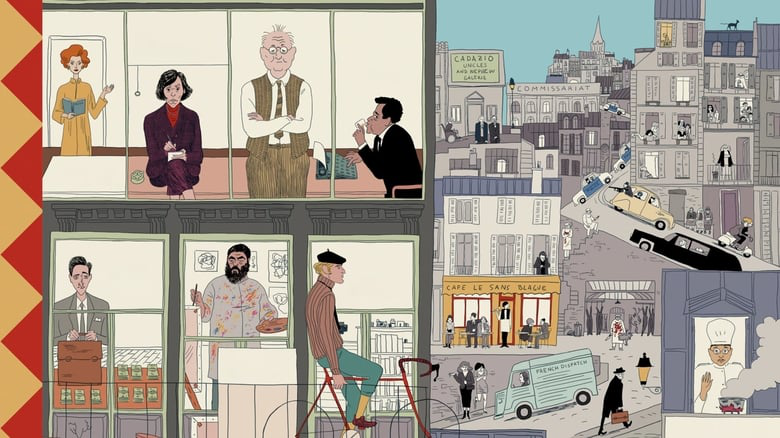

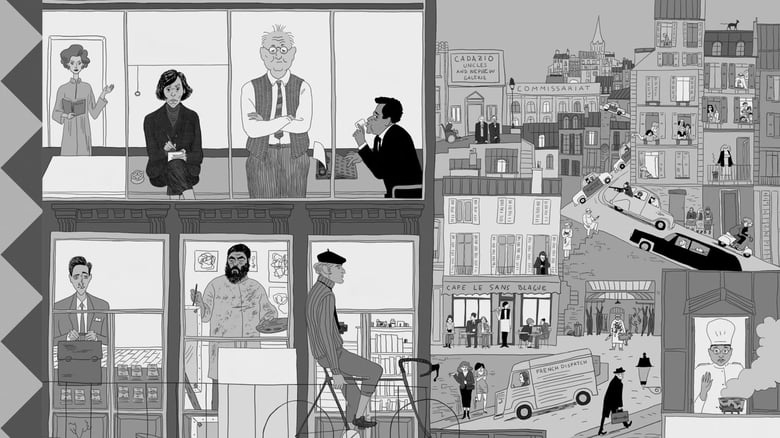

In [ ]:
# call image and pictures in python with suitable library:
from PIL import Image


image_path = r"C:\term10\ML\HW1\ورودی.jpg"
image = Image.open(image_path)


#  do same thing for display and showing our picture

from IPython.display import display
display(image)




# changing color
gray_image = image.convert("L")

# saving images
gray_image.save("output_gray.jpg")


#  display grayscale image
display(gray_image)


# **Section2:**  expression grayscale image as arrays of matrix

In [ ]:
 # when we want to work with arrays of matrix, we can use numpy library
import numpy as np

matrix = np.array(gray_image)

print(type(matrix))
print(matrix.shape)
print(matrix)

<class 'numpy.ndarray'>
(438, 780)
[[177 177 181 ... 183 183 183]
 [177 176 180 ... 183 183 183]
 [178 177 179 ... 183 183 183]
 ...
 [172 182 180 ... 236 236 236]
 [174 179 180 ... 236 236 236]
 [179 174 174 ... 236 236 236]]


# **Section3:**  subsizing grayscale pictur

Original size: (438, 780)
New size: (55, 98)


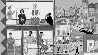

In [ ]:
# for this section I use 2 methods
# first I use nearest neighbor method for subsizing picture


# chose 8th nearest neighbor from each point
new_height = matrix.shape[0] // 8
new_width = matrix.shape[1] // 8


small_matrix = matrix[0::8, 0::8]

print("Original size:", matrix.shape)
print("New size:", small_matrix.shape)

# convert matrix to image again
small_image1 = Image.fromarray(small_matrix)
from IPython.display import display
display(small_image1)
small_image1.save("output_small_image1.jpg")

Original size: (438, 780)
New size: (109, 195)


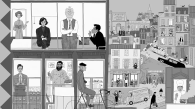

In [ ]:
#  second I convert my graysacle pictures matrix to n f*f matrix. then chose mean of this new matrix as new pixel/ i*J for previous matrix.

#defined this function below

def block_average_downsample(M, f):

    h, w = M.shape    # Initial image dimensions.

    new_h = h // f   # Matrix dimensions after reduction.
    new_w = w // f

    down = np.zeros((new_h, new_w))

    # Traversing the image matrix in f×f blocks:
    for i in range(new_h):           # Row traversal
        for j in range(new_w):       # Column traversal

            # Current block range:
            start_i = i * f
            end_i   = start_i + f
            start_j = j * f
            end_j   = start_j + f

            # Extracting the block
            block = M[start_i:end_i, start_j:end_j]

            #Averaging the block values
            down[i, j] = np.mean(block)

    return down
small_matrix2 = block_average_downsample(matrix,4)
print("Original size:", matrix.shape)
print("New size:", small_matrix2.shape)
scaled = (small_matrix2 - np.min(small_matrix2)) / (np.max(small_matrix2) - np.min(small_matrix2))
scaled = (scaled * 255).astype(np.uint8)

from PIL import Image
small_image2 = Image.fromarray(small_matrix2)
# توضییح این قسمت رو مجبور شدم فارسی بنویسم(امیدوارم ایرادی نداشته باشه) بعضی از درایه های ماتریس ممکنه که float  باشه و در پردازش گرافیکی باعث مشکل باشه و مجبوریم اول ماتریس خودمان را نرماله کنیم
scaled = (small_matrix2 - np.min(small_matrix2)) / (np.max(small_matrix2) - np.min(small_matrix2))
scaled = (scaled * 255).astype(np.uint8)
small_image2 = Image.fromarray(scaled)
from IPython.display import display
display(small_image2)





# **Section3:**  comparing subsized and orginal image

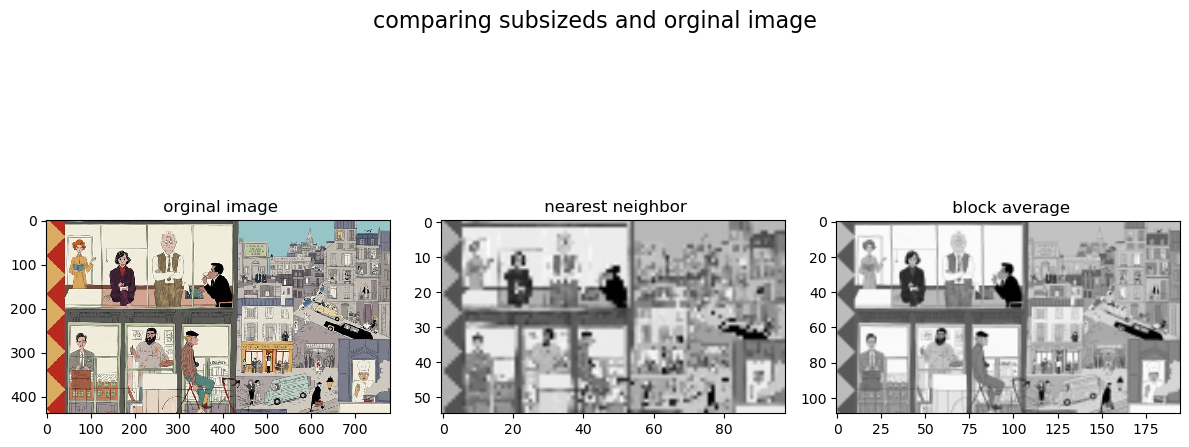

In [ ]:
import matplotlib.pyplot as plt


## "figsize=(12,6)" is the size of the entire window. Each image takes up half of this space.
# For this, we have a single row and three columns side by side to display the images.


fig, axes = plt.subplots(1, 3,  figsize=(12, 6))
fig.suptitle("comparing subsizeds and orginal image", fontsize=16)

 # showing original image
im0 = axes[0].imshow(image, interpolation='nearest') # 'nearest'  is function that automatically subsized image to fit in space without reduce quality of image
axes[0].set_title(" orginal image")


 # showing subsized images
im1 = axes[1].imshow(small_image1, cmap='gray', interpolation='bilinear')
axes[1].set_title(" nearest neighbor")


im1 = axes[2].imshow(small_image2, cmap='gray', interpolation='bilinear')
axes[2].set_title(" block average")





plt.tight_layout()
plt.show()